#### Stein Variational Gradient Descent
+ This notebook is for Stein Variational Inference:
+ target posterior $p(w|x^n)$ is approximated by $q(w)$ based on Stein Discrepancy $D(p, q)$:
$$
D(p, q) := \max_{\phi \in F} E_{w \sim q} [tr(A_{p}\phi(w))],
$$
+ where $A_p$ is stein's operator: $A_{p} \phi(w) = \nabla_w \log p^T(w|x^n) \phi(w) + \nabla_w \phi(w)$.
+ When $F$ is RKHS on $d$-dimensional, and the approximated distribution is $q(z)$, where $z = T(x) = x + \epsilon \phi(x)$,
+ then the the maximum direction $\phi^*_{q,p}$ of $\frac{d}{d\epsilon}KL(q|p) |_{\epsilon=0}$ is given by 
$$
\phi^*_{q,p}(\cdot) = E_{w \sim q} [tr(A_p k(w,\cdot))] \approx \sum_{l=1}^L \frac{1}{L} \Bigl\{ \nabla_w \log p(w_l|x^n) k(w_l,\cdot) + \nabla_w k(w_l, \cdot) \Bigr\}
$$

+ Based on the value, the sample of the posterior distribution $w^{(l)}$ is calculated iteratively:
$$
w^{(l+1)} = w^{(l)} + \epsilon \phi^*{q,p}(w^{(l)})
$$
+ where $\epsilon$ is step size, and should be gradually descreased like conventional gradient descent method.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

In [3]:
def rot_x(theta: float) -> np.ndarray:
    return np.array([
        [1, 0, 0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta), np.cos(theta)],
    ])

def rot_y(theta: float) -> np.ndarray:
    return np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)],
    ])

def rot_z(theta: float) -> np.ndarray:
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1],
    ])


In [4]:
def dt_rot_x(theta: float) -> np.ndarray:
    return np.array([
        [0, 0, 0],
        [0, -np.sin(theta), -np.cos(theta)],
        [0, np.cos(theta), -np.sin(theta)],
    ])

def dt_rot_y(theta: float) -> np.ndarray:
    return np.array([
        [-np.sin(theta), 0, np.cos(theta)],
        [0, 0, 0],
        [-np.cos(theta), 0, -np.sin(theta)],
    ])

def dt_rot_z(theta: float) -> np.ndarray:
    return np.array([
        [-np.sin(theta), -np.cos(theta), 0],
        [np.cos(theta), -np.sin(theta), 0],
        [0, 0, 0],
    ])



# First step
+ Check rotational gradient

In [5]:
thetas = np.random.normal(size=3)

In [6]:
thetas = [np.pi/5, np.pi/2, np.pi*1.2]

In [7]:
cz, sz = np.cos(thetas[0]), np.sin(thetas[0])
cy, sy = np.cos(thetas[1]), np.sin(thetas[1])
cx, sx = np.cos(thetas[2]), np.sin(thetas[2])

In [8]:
test1 = rot_z(thetas[0]) @ rot_y(thetas[1]) @ rot_x(thetas[2])

test2 = np.array([
    [cy*cz, -cx*sz+sx*sy*cz, sx*sz+cx*sy*cz],
    [cy*sz, cx*cz+sx*sy*sz, -sx*cz+cx*sy*sz],
    [-sy, sx*cy, cx*cy],
])

np.allclose(test1, test2)

True

In [9]:
test1 = rot_z(thetas[0]) @ rot_y(thetas[1]) @ dt_rot_x(thetas[2])

test2 = np.array([
    [0, sx*sz+cx*sy*cz, cx*sz-sx*sy*cz],
    [0, -sx*cz+cx*sy*sz, -cx*cz-sx*sy*sz],
    [0, cx*cy, -sx*cy],
])

np.allclose(test1, test2)

True

In [10]:
test2

array([[ 0.00000000e+00, -1.00000000e+00, -1.11022302e-16],
       [ 0.00000000e+00, -1.11022302e-16,  1.00000000e+00],
       [ 0.00000000e+00, -4.95380036e-17,  3.59914664e-17]])

In [11]:
test1 = rot_z(thetas[0]) @ dt_rot_y(thetas[1]) @ rot_x(thetas[2])

test2 = np.array([
    [-sy*cz, sx*cy*cz, cx*cy*cz],
    [-sy*sz, sx*cy*sz, cx*cy*sz],
    [-cy, -sx*sy, -cx*sy],
])

np.allclose(test1, test2)

True

In [12]:
test1 = dt_rot_z(thetas[0]) @ rot_y(thetas[1]) @ rot_x(thetas[2])

test2 = np.array([
    [-cy*sz, -cx*cz-sx*sy*sz, sx*cz-cx*sy*sz],
    [cy*cz, -cx*sz+sx*sy*cz, sx*sz+cx*sy*cz],
    [0, 0, 0],
])

np.allclose(test1, test2)

True

In [13]:
test2

array([[-3.59914664e-17,  1.00000000e+00,  1.11022302e-16],
       [ 4.95380036e-17,  1.11022302e-16, -1.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

# Next Step
+ Check algorithm by rigid transformation
+ $p(y|x,w) = N(y|Rx + t, I_M)$, and $R, t$ is learnable paramters

## Oridinal Case

### Data Generation

In [25]:
## dimension of input
M = 3

# number of samples
n = 100

data_seed = 20250108
np.random.seed(data_seed)

true_trans = np.array([5, -5, 5])
# true_mu = np.array([-10, 10])
# true_xyz_theta = np.array([np.pi/6, np.pi/2, -np.pi/4])
# true_xyz_theta = np.array([np.pi/5, np.pi/2, np.pi*1.2])
true_xyz_theta = np.array([np.pi/5, np.pi*0.75, np.pi*1.2])
true_rot = rot_z(true_xyz_theta[2]) @ rot_y(true_xyz_theta[1]) @ rot_x(true_xyz_theta[0])

train_X = np.random.normal(size=(n, M))
train_Y = train_X @ true_rot.T + true_trans + 0.1 * np.random.normal(size=(n, M))

In [26]:
true_rot

array([[ 0.5720614 ,  0.139279  , -0.8082989 ],
       [ 0.41562694, -0.89880788,  0.139279  ],
       [-0.70710678, -0.41562694, -0.5720614 ]])

### Hyperparameters
+ kernel function: modified Radial Basis Kernel $\exp(-\frac{1}{2h^2} \sum_k (t_k - t_k')^2) \times \exp(-\frac{1}{2h^2} \sum_k (\arctan2 (\sin(\theta_k - \theta'_k), \cos(\theta_k - \theta'_k))^2)$
+ prior: multivariate distribution and von mises distribution $\prod_k N(t_k|0, \beta^{-1}) \prod_k vonmises(\theta_k|0, \kappa)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times M}$, $L$ is the number of sample from the approximated posterior

In [27]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 1
pri_kappa = 1

L = 100
initial_post_param = np.hstack([
    np.random.normal(size=(L, 3)),
    np.random.vonmises(0, 1, size=(L, 3)),
])

h = 1
first_step_size = 0.05

### Learning

In [28]:
n_ite = 500
post_param = initial_post_param.copy()

disp_cycle = 50

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0

for ite in range(n_ite):
    diff_param = post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]
    diff_trans = diff_param[:,:,:3]
    diff_theta = diff_param[:,:,3:]
    
    dist = (diff_trans ** 2).sum(axis=2) + (np.arctan2(np.sin(diff_theta), np.cos(diff_theta)) ** 2).sum(axis = 2)
    
    h = 0.5*np.median(dist[np.triu_indices(L, k=1)])**2/np.log(L)
    
    kernel_post = np.exp(-dist/(2*h**2))
    
    dw_kernel_post = np.hstack([
        (diff_trans * kernel_post[:,:,np.newaxis]).sum(axis=0) / (h**2),
        (np.arctan2(np.sin(diff_theta), np.cos(diff_theta)) * kernel_post[:,:,np.newaxis]).sum(axis=0) / (h**2),
    ])
    
    rot_x_post = [rot_x(theta) for theta in post_param[:,3]]
    rot_y_post = [rot_y(theta) for theta in post_param[:,4]]
    rot_z_post = [rot_z(theta) for theta in post_param[:,5]]
    post_trans = post_param[:,:3]
    
    rots_x = np.array([rotz@roty@rotx@train_X.sum(axis=0)  for rotz, roty, rotx in zip(rot_z_post, rot_y_post, rot_x_post)])
    dtrans_logp = train_Y.sum(axis=0)[np.newaxis,:] - n*post_trans - rots_x - pri_beta/2*post_trans
    
    cov_YX = train_Y.T @ train_X
    sum_X = train_X.sum(axis=0)
    dtheta_z_logp = np.array([
        np.trace((dt_rot_z(theta_z) @ roty @ rotx).T @ cov_YX) 
        - trans_vec @ dt_rot_z(theta_z) @ roty @ rotx @ sum_X
        for theta_z, roty, rotx, trans_vec in zip(post_param[:,5], rot_y_post, rot_x_post, post_trans)
    ]) - pri_kappa * np.sin(post_param[:,5])
    
    dtheta_y_logp = np.array([
        np.trace((rotz @ dt_rot_y(theta_y) @ rotx).T @ cov_YX) 
        - trans_vec @ rotz @ dt_rot_y(theta_y) @ rotx @ sum_X
        for rotz, theta_y, rotx, trans_vec in zip(rot_z_post, post_param[:,4], rot_x_post, post_trans)
    ]) - pri_kappa * np.sin(post_param[:,4])
    
    dtheta_x_logp = np.array([
        np.trace((rotz @ roty @ dt_rot_x(theta_x)).T @ cov_YX) 
        - trans_vec @ rotz @ roty @ dt_rot_x(theta_x) @ sum_X
        for rotz, roty, theta_x, trans_vec in zip(rot_z_post, rot_y_post, post_param[:,3], post_trans)
    ]) - pri_kappa * np.sin(post_param[:,3])
    
    dw_logp = np.block([
        dtrans_logp, dtheta_x_logp[:,np.newaxis], dtheta_y_logp[:,np.newaxis], dtheta_z_logp[:,np.newaxis]
    ])
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L
    
    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    # step_size = first_step_size / (ite + 1)
    # step_size = first_step_size
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    # calc stein discrepancy
    dw_partial_kernel = -1/h**2 * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
    dwdw_kernel = (1/h**2 * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2 / (2*h**2) ))
    # divergence of phi
    div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
    dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()
    stein_discrepancy = dw_logp_phi + div_phi
    
    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, step_size = {}, stein_discrepancy = {}".format(ite, post_param[0], h, step_size[0], stein_discrepancy))

ite = 0, post_param = [-0.48587376 -0.67252822 -0.24739504 -0.65844148 -0.74739654 -1.58012186], h = 17.00867945920435, step_size = [0.00010276 0.0001028  0.0001006  0.00726603 0.00121584 0.00219954], stein_discrepancy = 732721.9453548416
ite = 50, post_param = [ 1.78949877 -2.94879547  2.0306667  -2.29949357  0.16426466 -0.3363429 ], h = 16.504880758420317, step_size = [0.00016424 0.00016398 0.00015995 0.01389114 0.00945333 0.01008069], stein_discrepancy = 214949.21881295115
ite = 100, post_param = [ 3.74915622 -4.90436547  4.00472149 -2.99173792  0.34562749 -0.37822459], h = 12.946163857822075, step_size = [0.00046377 0.000466   0.00044123 0.01813707 0.0203576  0.01591565], stein_discrepancy = 15944.499052567297
ite = 150, post_param = [ 4.49713508 -5.56748184  4.77093364 -3.22704335  0.47376961 -0.26836528], h = 8.226524267212689, step_size = [0.0046255  0.00474556 0.00430141 0.01061389 0.01366753 0.00970221], stein_discrepancy = 470.84401659302495
ite = 200, post_param = [ 4.907503

In [30]:
true_trans, true_xyz_theta

(array([ 5, -5,  5]), array([0.62831853, 2.35619449, 3.76991118]))

In [31]:
np.array([
    rot_z(theta_z) @ rot_y(theta_y) @ rot_x(theta_x)
    for theta_z, theta_y, theta_x in zip(post_param[:,5], post_param[:,4], post_param[:,3])
]).mean(axis=0)

array([[ 0.56634397,  0.14690052, -0.80950852],
       [ 0.42343999, -0.89389606,  0.13426396],
       [-0.70586179, -0.42041794, -0.56839337]])

In [32]:
true_rot

array([[ 0.5720614 ,  0.139279  , -0.8082989 ],
       [ 0.41562694, -0.89880788,  0.139279  ],
       [-0.70710678, -0.41562694, -0.5720614 ]])

In [33]:
post_param[:,:3].mean(axis=0)

array([ 4.98430689, -4.9882426 ,  4.99035683])

In [34]:
rot_z(post_param[0,5]) @ rot_y(post_param[0,4]) @ rot_x(post_param[0,3])

array([[ 0.54476415,  0.17630083, -0.81984757],
       [ 0.42692256, -0.89977958,  0.09018776],
       [-0.72178192, -0.39914249, -0.56543446]])

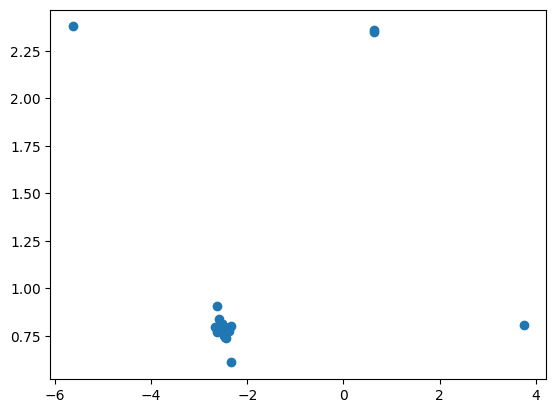

In [35]:
plt.scatter(post_param[:,3], post_param[:,4])
plt.show()

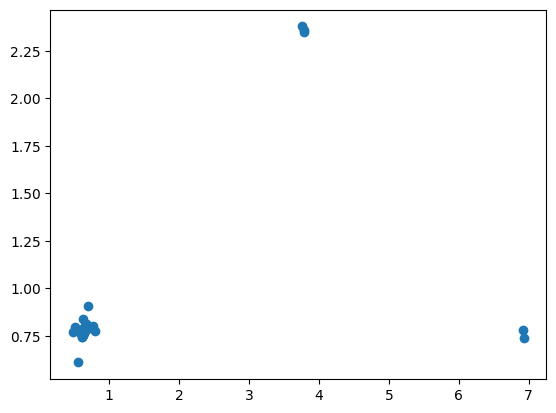

In [36]:
plt.scatter(post_param[:,5], post_param[:,4])
plt.show()

## Gimbal Lock case
+ When $\theta_y = \pi/2$, then the distribution of $theta_x$ and $theta_z$ are widespread.

### Data Generation

In [37]:
## dimension of input
M = 3

# number of samples
n = 100

data_seed = 20250108
np.random.seed(data_seed)

true_trans = np.array([5, -5, 5])
# true_mu = np.array([-10, 10])
# true_xyz_theta = np.array([np.pi/6, np.pi/2, -np.pi/4])
true_xyz_theta = np.array([np.pi/5, np.pi/2, np.pi*1.2])
true_rot = rot_z(true_xyz_theta[2]) @ rot_y(true_xyz_theta[1]) @ rot_x(true_xyz_theta[0])

train_X = np.random.normal(size=(n, M))
train_Y = train_X @ true_rot.T + true_trans + 0.1 * np.random.normal(size=(n, M))

In [38]:
true_rot

array([[-4.95380036e-17, -9.83623360e-17, -1.00000000e+00],
       [-3.59914664e-17, -1.00000000e+00,  1.02478896e-16],
       [-1.00000000e+00,  3.59914664e-17,  4.95380036e-17]])

### Hyperparameters
+ kernel function: modified Radial Basis Kernel $\exp(-\frac{1}{2h^2} \sum_k (t_k - t_k')^2) \times \exp(-\frac{1}{2h^2} \sum_k (\arctan2 (\sin(\theta_k - \theta'_k), \cos(\theta_k - \theta'_k))^2)$
+ prior: multivariate distribution and von mises distribution $\prod_k N(t_k|0, \beta^{-1}) \prod_k vonmises(\theta_k|0, \kappa)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times M}$, $L$ is the number of sample from the approximated posterior

In [39]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 1
pri_kappa = 1

L = 100
initial_post_param = np.hstack([
    np.random.normal(size=(L, 3)),
    np.random.vonmises(0, 1, size=(L, 3)),
])

h = 1
first_step_size = 0.05

### Learning

In [40]:
n_ite = 500
post_param = initial_post_param.copy()

disp_cycle = 50

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0

for ite in range(n_ite):
    diff_param = post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]
    diff_trans = diff_param[:,:,:3]
    diff_theta = diff_param[:,:,3:]
    
    dist = (diff_trans ** 2).sum(axis=2) + (np.arctan2(np.sin(diff_theta), np.cos(diff_theta)) ** 2).sum(axis = 2)
    
    h = 0.5*np.median(dist[np.triu_indices(L, k=1)])**2/np.log(L)
    
    kernel_post = np.exp(-dist/(2*h**2))
    
    dw_kernel_post = np.hstack([
        (diff_trans * kernel_post[:,:,np.newaxis]).sum(axis=0) / (h**2),
        (np.arctan2(np.sin(diff_theta), np.cos(diff_theta)) * kernel_post[:,:,np.newaxis]).sum(axis=0) / (h**2),
    ])
    
    rot_x_post = [rot_x(theta) for theta in post_param[:,3]]
    rot_y_post = [rot_y(theta) for theta in post_param[:,4]]
    rot_z_post = [rot_z(theta) for theta in post_param[:,5]]
    post_trans = post_param[:,:3]
    
    rots_x = np.array([rotz@roty@rotx@train_X.sum(axis=0)  for rotz, roty, rotx in zip(rot_z_post, rot_y_post, rot_x_post)])
    dtrans_logp = train_Y.sum(axis=0)[np.newaxis,:] - n*post_trans - rots_x - pri_beta/2*post_trans
    
    cov_YX = train_Y.T @ train_X
    sum_X = train_X.sum(axis=0)
    dtheta_z_logp = np.array([
        np.trace((dt_rot_z(theta_z) @ roty @ rotx).T @ cov_YX) 
        - trans_vec @ dt_rot_z(theta_z) @ roty @ rotx @ sum_X
        for theta_z, roty, rotx, trans_vec in zip(post_param[:,5], rot_y_post, rot_x_post, post_trans)
    ]) - pri_kappa * np.sin(post_param[:,5])
    
    dtheta_y_logp = np.array([
        np.trace((rotz @ dt_rot_y(theta_y) @ rotx).T @ cov_YX) 
        - trans_vec @ rotz @ dt_rot_y(theta_y) @ rotx @ sum_X
        for rotz, theta_y, rotx, trans_vec in zip(rot_z_post, post_param[:,4], rot_x_post, post_trans)
    ]) - pri_kappa * np.sin(post_param[:,4])
    
    dtheta_x_logp = np.array([
        np.trace((rotz @ roty @ dt_rot_x(theta_x)).T @ cov_YX) 
        - trans_vec @ rotz @ roty @ dt_rot_x(theta_x) @ sum_X
        for rotz, roty, theta_x, trans_vec in zip(rot_z_post, rot_y_post, post_param[:,3], post_trans)
    ]) - pri_kappa * np.sin(post_param[:,3])
    
    dw_logp = np.block([
        dtrans_logp, dtheta_x_logp[:,np.newaxis], dtheta_y_logp[:,np.newaxis], dtheta_z_logp[:,np.newaxis]
    ])
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L
    
    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    # step_size = first_step_size / (ite + 1)
    # step_size = first_step_size
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    # calc stein discrepancy
    dw_partial_kernel = -1/h**2 * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
    dwdw_kernel = (1/h**2 * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2 / (2*h**2) ))
    # divergence of phi
    div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
    dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()
    stein_discrepancy = dw_logp_phi + div_phi
    
    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, step_size = {}, stein_discrepancy = {}".format(ite, post_param[0], h, step_size[0], stein_discrepancy))

ite = 0, post_param = [-0.48587376 -0.67252822 -0.24739504 -0.55844148 -0.74739654 -1.58012186], h = 17.00867945920435, step_size = [1.01968697e-04 1.03385690e-04 9.96920792e-05 5.24765111e-03
 7.14657276e-04 2.78968708e-03], stein_discrepancy = 741435.4761492107
ite = 50, post_param = [ 1.79086757 -2.94738883  2.03198874 -1.59995644  0.51262195  0.3558701 ], h = 16.67626313736225, step_size = [0.00016256 0.00016539 0.0001581  0.01436087 0.00439434 0.00605139], stein_discrepancy = 217327.0375228592
ite = 100, post_param = [ 3.75632119 -4.89760551  4.01154897 -1.6413304   0.82970997  1.03916093], h = 14.330165382608373, step_size = [0.00045472 0.00047407 0.0004322  0.01509588 0.01435415 0.01433112], stein_discrepancy = 16326.51820203087
ite = 150, post_param = [ 4.49855049 -5.55346059  4.78110049 -1.63273424  1.06769334  1.4229694 ], h = 11.520261071642793, step_size = [0.00451222 0.00487844 0.00418039 0.01151644 0.01321636 0.01132633], stein_discrepancy = 294.7972089566429
ite = 200, p

In [41]:
true_trans, true_xyz_theta

(array([ 5, -5,  5]), array([0.62831853, 1.57079633, 3.76991118]))

In [42]:
np.array([
    rot_z(theta_z) @ rot_y(theta_y) @ rot_x(theta_x)
    for theta_z, theta_y, theta_x in zip(post_param[:,5], post_param[:,4], post_param[:,3])
]).mean(axis=0)

array([[ 0.00876143, -0.04540324, -0.99519057],
       [ 0.00228929, -0.99466144,  0.04536436],
       [-0.99742243, -0.00233355, -0.00846827]])

In [43]:
true_rot

array([[-4.95380036e-17, -9.83623360e-17, -1.00000000e+00],
       [-3.59914664e-17, -1.00000000e+00,  1.02478896e-16],
       [-1.00000000e+00,  3.59914664e-17,  4.95380036e-17]])

In [44]:
post_param[:,:3].mean(axis=0)

array([ 5.0109332 , -4.96143642,  4.96457312])

In [45]:
rot_z(post_param[0,5]) @ rot_y(post_param[0,4]) @ rot_x(post_param[0,3])

array([[ 0.02120789, -0.07189256, -0.99718689],
       [ 0.03536896, -0.99673293,  0.07261205],
       [-0.99914927, -0.03680941, -0.01859583]])

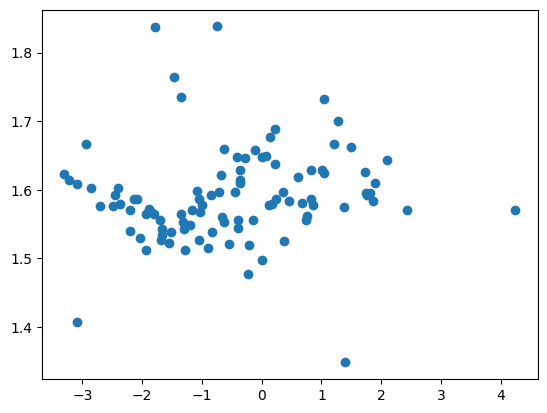

In [46]:
plt.scatter(post_param[:,3], post_param[:,4])
plt.show()

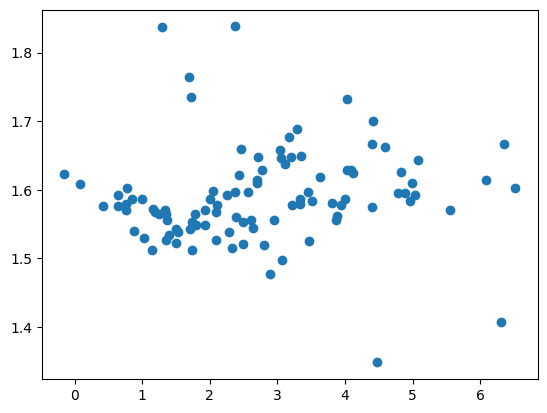

In [47]:
plt.scatter(post_param[:,5], post_param[:,4])
plt.show()